<a href="https://colab.research.google.com/github/abmppina/gserm_summer_school/blob/main/exam_exercise_improved_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="center" style="max-width: 1000px" src="https://github.com/HSG-AIML-Teaching/GSERM2026-Lab/blob/main/assignment/banner.png?raw=1">

<img align="right" style="max-width: 200px; height: auto" src="https://github.com/HSG-AIML-Teaching/GSERM2026-Lab/blob/main/assignment/hsg_logo.png?raw=1">

##  Assignment - Fashion MNIST Convolutional Neural Networks (CNNs)

GSERM'26 course "Deep Learning: Fundamentals and Applications", University of St. Gallen

This week we have learned how to enhance vanilla Artificial Neural Networks (ANNs) using `PyTorch` to classify even more complex images. For this purpose, we used a special type of deep neural network referred to **Convolutional Neural Networks (CNNs)**. In our exam exercise, we aim to leverage that knowledge by applying it to the known Fashion-MNIST dataset.

As always, pls. don't hesitate to post your potential questions on CANVAS (StudyNet) forum (https://learning.unisg.ch), or send us an email (using the course email: aiml-teaching.ics@unisg.ch).

## 1. Assignment Objectives:

As discussed in our last session, these are the tasks for the exam exercise:

> 1. Load the Fashion **MNIST dataset**.
> 2. Implement a **CNN** architecture able to work with this data.
> 3. **Train** the model, evaluate its **performance** and visualize the results.
> 4. Try to **improve** the performance of the initial model.
> 5. **Document** the results in the form of PowerPoint slides.

## 2. Setup of the Jupyter Notebook Environment

Similar to the previous labs, we need to import a couple of Python libraries that allow for data analysis and data visualization. We will mostly use the `PyTorch`, `Numpy`, `Sklearn`, `Matplotlib`, `Seaborn` and a few utility libraries throughout this lab:

In [2]:
# import standard python libraries
import os, urllib, io
from datetime import datetime, timezone, UTC
import numpy as np
import pandas as pd
from collections import Counter

Import Python machine / deep learning libraries:

In [3]:
# import the PyTorch deep learning library
import torch, torchvision
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable

Import the sklearn classification metrics:

In [4]:
# import sklearn classification evaluation library
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

Import Python plotting libraries:

In [5]:
# import matplotlib, seaborn, and PIL data visualization libary
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Enable notebook matplotlib inline plotting:

In [6]:
%matplotlib inline

Import Google's GDrive connector and mount your GDrive directories:

In [7]:
# import the Google Colab GDrive connector
from google.colab import drive

# mount GDrive inside the Colab notebook
drive.mount('/content/drive')

Mounted at /content/drive


Create a structure of Colab Notebook sub-directories inside of GDrive to store (1) the data as well as (2) the trained neural network models:

In [8]:
# create Colab Notebooks directory
notebook_directory = '/content/drive/MyDrive/Colab Notebooks'
if not os.path.exists(notebook_directory): os.makedirs(notebook_directory)

 # create data sub-directory inside the Colab Notebooks directory
data_directory = '/content/drive/MyDrive/Colab Notebooks/data'
if not os.path.exists(data_directory): os.makedirs(data_directory)

 # create models sub-directory inside the Colab Notebooks directory
models_directory = '/content/drive/MyDrive/Colab Notebooks/models'
if not os.path.exists(models_directory): os.makedirs(models_directory)

Set a random `seed` value to obtain reproducable results:

In [9]:
# init deterministic seed
seed_value = 1234
np.random.seed(seed_value) # set numpy seed
torch.manual_seed(seed_value) # set pytorch seed CPU

Google Colab provides the use of free GPUs for running notebooks. However, if you just execute this notebook as is, it will use your device's CPU. To run the lab on a GPU, got to `Runtime` > `Change runtime type` and set the Runtime type to `GPU` in the drop-down. Running this lab on a CPU is fine, but you will find that GPU computing is faster. *CUDA* indicates that the lab is being run on GPU.

Enable GPU computing by setting the `device` flag and init a `CUDA` seed:

In [10]:
# set cpu or gpu enabled device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu').type

# init deterministic GPU seed
torch.cuda.manual_seed(seed_value)

# log type of device enabled
print('[LOG] notebook with {} computation enabled'.format(str(device)))

[LOG] notebook with cuda computation enabled


Let's determine if we have access to a GPU provided by e.g. Google's COLab environment:

In [11]:
!nvidia-smi

Sat Jun 27 07:54:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Exam Exercise: Convolutional Neural Networks (CNNs)

The **Fashion-MNIST database** is a large database of Zalando articles that is commonly used for training various image processing systems. The database is widely used for training and testing in the field of machine learning. Source: https://www.kaggle.com/c/insar-fashion-mnist-challenge

### 3.1 Fashion-MNIST Dataset Download and Data Assessment

#### 3.1.1 Setup & Inspect Training Dataset

In [12]:
# Path to store training data
train_path = data_directory + '/train_fmnist'

In [13]:
# define pytorch transformation into tensor format, aka, transforming a 2D image into a vector with 3 components and converting pixels to boleans (channel, height, width) https://docs.pytorch.org/vision/0.9/transforms.html
# Compose is just a function to implement multiple transformations. In this case, wer're just converting ToTensor() and also normalize using std and mean of the dataset.
transf = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),torchvision.transforms.Normalize((0.2860,), (0.3530,))])

# Download and transform dataset using the variable transf defined above : Guidelines: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST
fashion_mnist_train_data = torchvision.datasets.FashionMNIST(root=train_path, train=True, transform=transf, download=True)

In [14]:
# Check dataset size. Training dataset should be 60k (reference: https://github.com/zalandoresearch/fashion-mnist)

print(len(fashion_mnist_train_data))

60000


<class 'torch.Tensor'>
torch.Size([1, 28, 28])
torch.float32


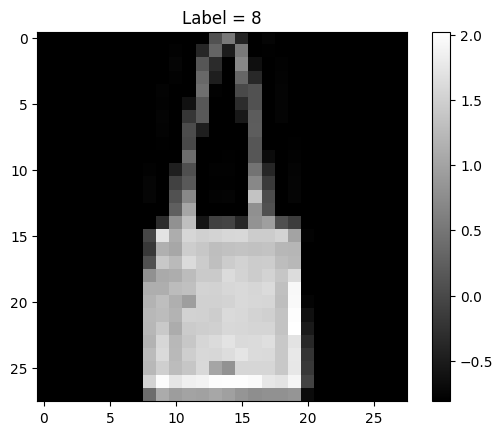

In [16]:
# Inspect one single image: bag...
image, label = fashion_mnist_train_data[200]

print(type(image))
print(image.shape)
print(image.dtype)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label = {label}")
plt.colorbar()
plt.show()

In [17]:
# Map the numerical labels to text
fashion_labels = {0: 'T-shirt/top',
                    1: 'Trouser',
                    2: 'Pullover',
                    3: 'Dress',
                    4: 'Coat',
                    5: 'Sandal',
                    6: 'Shirt',
                    7: 'Sneaker',
                    8: 'Bag',
                    9: 'Ankle boot'}

In [18]:
# Confirm that the mapping is correct for the given image retrieved
print(label)
print(fashion_labels[label])

8
Bag


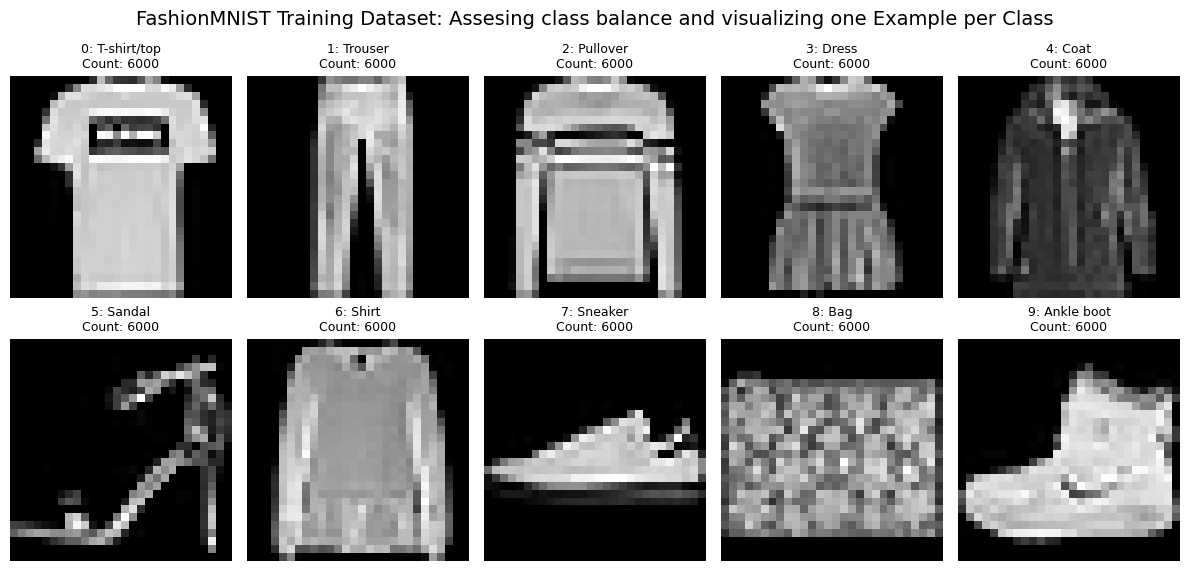

In [19]:
# Count samples per class
labels = [label for _, label in fashion_mnist_train_data]
counts = Counter(labels)

# Find one example for each class
examples = {}

for image, label in fashion_mnist_train_data:
    if label not in examples:
        examples[label] = image

    if len(examples) == 10:
        break

# Plot 10 examples of images...
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for class_id, ax in enumerate(axes.flatten()):
    image = examples[class_id]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(
        f"{class_id}: {fashion_labels[class_id]}\nCount: {counts[class_id]}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("FashionMNIST Training Dataset: Assesing class balance and visualizing one Example per Class", fontsize=14)
plt.tight_layout()
plt.show()

#### 3.1.2 Setup & Inspect Evaluation Dataset

In [20]:
# Path to store evaluation data
eval_path = data_directory + '/eval_fmnist'

In [21]:
# Download and transform dataset using the variable transf defined above : Guidelines: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST
fashion_mnist_eval_data = torchvision.datasets.FashionMNIST(root=eval_path, train=False, transform=transf, download=True)

In [22]:
# Check dataset size. Evaluation dataset should be 10k (reference: https://github.com/zalandoresearch/fashion-mnist)

print(len(fashion_mnist_eval_data))

10000


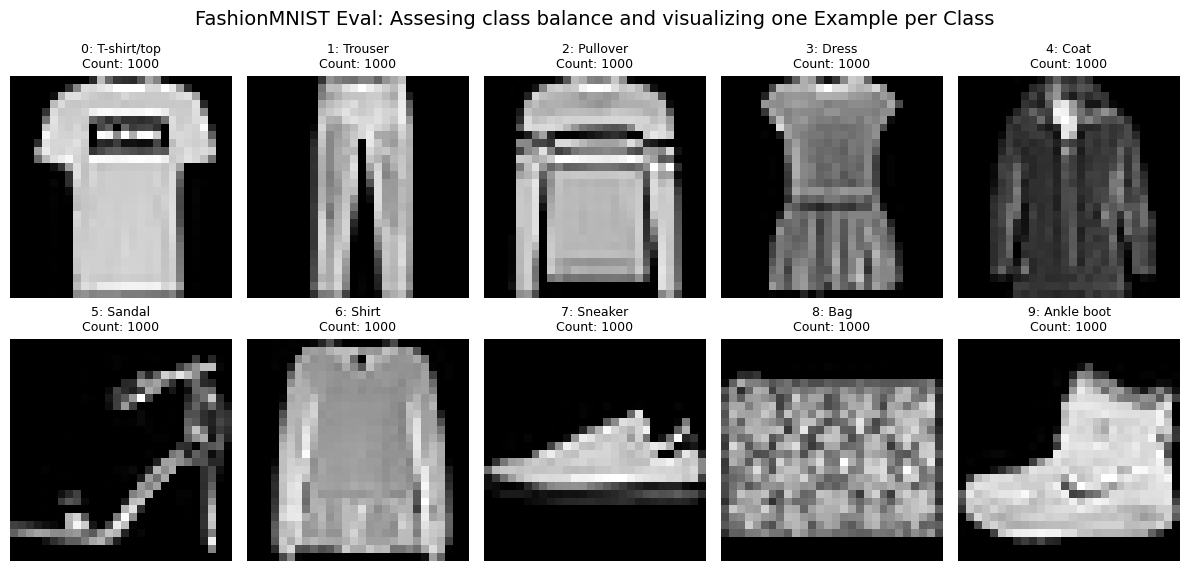

In [23]:
# Count samples per class
labels = [label for _, label in fashion_mnist_eval_data]
counts = Counter(labels)

# Find one example for each class
examples = {}

for image, label in fashion_mnist_train_data:
    if label not in examples:
        examples[label] = image

    if len(examples) == 10:
        break

# Plot 10 examples...
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for class_id, ax in enumerate(axes.flatten()):
    image = examples[class_id]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(
        f"{class_id}: {fashion_labels[class_id]}\nCount: {counts[class_id]}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("FashionMNIST Eval: Assesing class balance and visualizing one Example per Class", fontsize=14)
plt.tight_layout()
plt.show()

####3.1.3 Develop intuition on the classification problem

In [24]:
def compute_dataset_metrics(dataset, labels_map):
    images_by_class = {i: [] for i in range(10)}

    for image, label in dataset:
        images_by_class[label].append(image)

    avg_images = {}
    std_images = {}

    for label in range(10):
        stacked = torch.stack(images_by_class[label])
        avg_images[label] = stacked.mean(dim=0)
        std_images[label] = stacked.std(dim=0)

    within_variability = {
        label: std_images[label].mean().item()
        for label in range(10)
    }

    avg_vectors = {
        label: avg_images[label].flatten()
        for label in range(10)
    }

    rows = []

    for label in range(10):
        distances = {}

        for other_label in range(10):
            if label == other_label:
                continue

            distances[other_label] = torch.norm(
                avg_vectors[label] - avg_vectors[other_label]
            ).item()

        nearest_label = min(distances, key=distances.get)
        nearest_distance = distances[nearest_label]

        rows.append({
            "class_id": label,
            "class_name": labels_map[label],
            "count": len(images_by_class[label]),
            "within_class_variability": within_variability[label],
            "nearest_class_id": nearest_label,
            "nearest_class_name": labels_map[nearest_label],
            "distance_to_nearest_class": nearest_distance,
            "difficulty_score": within_variability[label] / nearest_distance,
        })

    return pd.DataFrame(rows)

In [25]:
train_metrics = compute_dataset_metrics(
    fashion_mnist_train_data,
    fashion_labels
)

eval_metrics = compute_dataset_metrics(
    fashion_mnist_eval_data,
    fashion_labels
)

In [26]:
train_metrics["dataset"] = "train"
eval_metrics["dataset"] = "eval"

all_metrics = pd.concat(
    [train_metrics, eval_metrics],
    ignore_index=True
)

all_metrics = all_metrics[
    [
        "dataset",
        "class_id",
        "class_name",
        "count",
        "within_class_variability",
        "nearest_class_name",
        "distance_to_nearest_class",
        "difficulty_score",
    ]
]


In [27]:
comparison_table = train_metrics.merge(
    eval_metrics,
    on=["class_id", "class_name"],
    suffixes=("_train", "_eval")
)

comparison_table[
    [
        "class_name",
        "count_train",
        "count_eval",
        "within_class_variability_train",
        "within_class_variability_eval",
        "nearest_class_name_train",
        "nearest_class_name_eval",
        "distance_to_nearest_class_train",
        "distance_to_nearest_class_eval",
        "difficulty_score_train",
        "difficulty_score_eval",
    ]
]

,class_name,count_train,count_eval,within_class_variability_train,within_class_variability_eval,nearest_class_name_train,nearest_class_name_eval,distance_to_nearest_class_train,distance_to_nearest_class_eval,difficulty_score_train,difficulty_score_eval
0,T-shirt/top,6000,1000,0.581020,0.578396,Shirt,Shirt,10.526992,10.274616,0.055193,0.056294
1,Trouser,6000,1000,0.406299,0.404498,Dress,Dress,11.613289,11.414703,0.034986,0.035437
2,Pullover,6000,1000,0.632555,0.625319,Coat,Coat,7.033131,6.644156,0.089939,0.094116
3,Dress,6000,1000,0.488998,0.499415,Trouser,Trouser,11.613289,11.414703,0.042107,0.043752
4,Coat,6000,1000,0.570279,0.578412,Pullover,Pullover,7.033131,6.644156,0.081085,0.087056
5,Sandal,6000,1000,0.542498,0.536856,Sneaker,Sneaker,10.873952,11.219524,0.049890,0.047850
6,Shirt,6000,1000,0.647609,0.649988,Pullover,Pullover,7.578393,7.359656,0.085455,0.088318
7,Sneaker,6000,1000,0.372723,0.356976,Sandal,Sandal,10.873952,11.219524,0.034277,0.031817
8,Bag,6000,1000,0.753594,0.753385,Shirt,Shirt,15.191866,14.943924,0.049605,0.050414
9,Ankle boot,6000,1000,0.547742,0.551364,Bag,Bag,17.440332,17.526737,0.031407,0.031458


Training dataset and evaluation dataset have similar distributions within class and interclasse. So, if we can get a good performance on the training dataset, it 'should' generalize well on the eval dataset.

Solely looking at within class variability and distance to other classes, we can develop some intuition towards which classes may be harder to classify by our model...

Data exploration in more detail here: https://docs.google.com/spreadsheets/d/13s4KEsnsaYFNPdR5Kr2TrpHtbNxNSibSri4Ycu4j1mk/edit?gid=0#gid=0

**Top 3**

* Pullovers --> Coats
* Shirts --> Pullovers
* Coats --> Pullovers

### 3.2 Convolutional Neural Network (CNN) Model Training and Evaluation

**ADD HERE AN IMAGE OF THE ARCHITECTURE**

What we learned so far from the dataset that should inform the architecture decision?



*   Images are small (28x28), containing 784 pixels, meaning we shouldn't need a very deep network to learn the feature space
*   Images are grey scale, so we don't need more than 1 channel and the model needs to learn primarily shapes, edges and contours
* Some classes are visually similar, as we saw in the data exploration section. Our network needs to learn a hierarchy of feature space. Probably 1 conv layer won't be enough to do so.



#### 3.2.1 Define and init neural network architectur

In [28]:
class FashionMNISTNet(nn.Module):

    def __init__(self):
        super(FashionMNISTNet, self).__init__()

        # Conv1:
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=5,
            stride=1,
            padding=0
        )

        # Pool1:
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv2:
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=5,
            stride=1,
            padding=0
        )

        # Pool2:
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.linear1 = nn.Linear(32 * 4 * 4, 120)
        self.relu1 = nn.ReLU(inplace=True)

        self.linear2 = nn.Linear(120, 84)
        self.relu2 = nn.ReLU(inplace=True)


        self.linear3 = nn.Linear(84, 10)

        # For NLLLoss
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, images):

        # Input: [batch_size, 1, 28, 28]

        x = self.pool1(self.relu1(self.conv1(images)))
        # [batch_size, 16, 12, 12]

        x = self.pool2(self.relu2(self.conv2(x)))
        # [batch_size, 32, 4, 4]

        x = x.view(-1, 32 * 4 * 4)
        # [batch_size, 256]

        x = self.relu1(self.linear1(x))

        x = self.relu2(self.linear2(x))

        x = self.logsoftmax(self.linear3(x))

        return x

In [29]:
model = FashionMNISTNet()

In [30]:
model = model.to(device)

In [31]:
!nvidia-smi

Sat Jun 27 08:24:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             25W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
# print the initialized architectures
print('[LOG] FashionMNISTNet architecture:\n\n{}\n'.format(model))

[LOG] FashionMNISTNet architecture:

FashionMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=512, out_features=120, bias=True)
  (relu1): ReLU(inplace=True)
  (linear2): Linear(in_features=120, out_features=84, bias=True)
  (relu2): ReLU(inplace=True)
  (linear3): Linear(in_features=84, out_features=10, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)



#### 3.2.2 Parameters & Loss Function definition

In [33]:
# init the number of model parameters
num_params = 0

# iterate over the distinct parameters
for param in model.parameters():

    # collect number of parameters
    num_params += param.numel()

# print the number of model paramters
print('[LOG] Number of to be trained FashionMNISTNet model parameters: {}.'.format(num_params))

[LOG] Number of to be trained FashionMNISTNet model parameters: 85822.


In [34]:
# define the optimization criterion / loss function
nll_loss = nn.NLLLoss()

In [35]:
nll_loss = nll_loss.to(device)

In [36]:
!nvidia-smi

Sat Jun 27 08:25:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P0             26W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [37]:
# define learning rate and optimization strategy
learning_rate = 0.01
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)

#### 3.2.3 Intution on what's happening for a given image

In [49]:
model = FashionMNISTNet()
model.eval()

image, label = fashion_mnist_train_data[234]

x = image.unsqueeze(0)  # add batch dimension: [1, 1, 28, 28]

print(x.shape)

torch.Size([1, 1, 28, 28])


In [50]:
with torch.no_grad():
    conv1_out = model.conv1(x)
    relu1_out = model.relu1(conv1_out)
    pool1_out = model.pool1(relu1_out)

    conv2_out = model.conv2(pool1_out)
    relu2_out = model.relu2(conv2_out)
    pool2_out = model.pool2(relu2_out)

print("Input:     ", x.shape)
print("Conv1:     ", conv1_out.shape)
print("ReLU1:     ", relu1_out.shape)
print("Pool1:     ", pool1_out.shape)
print("Conv2:     ", conv2_out.shape)
print("ReLU2:     ", relu2_out.shape)
print("Pool2:     ", pool2_out.shape)

Input:      torch.Size([1, 1, 28, 28])
Conv1:      torch.Size([1, 16, 24, 24])
ReLU1:      torch.Size([1, 16, 24, 24])
Pool1:      torch.Size([1, 16, 12, 12])
Conv2:      torch.Size([1, 32, 8, 8])
ReLU2:      torch.Size([1, 32, 8, 8])
Pool2:      torch.Size([1, 32, 4, 4])


In [51]:

def show_channels(tensor, title):

    tensor = tensor.squeeze(0)  # remove batch dimension

    n_channels = tensor.shape[0]

    fig, axes = plt.subplots(
        1,
        n_channels,
        figsize=(2*n_channels, 2)
    )

    if n_channels == 1:
        axes = [axes]

    for i in range(n_channels):
        axes[i].imshow(
            tensor[i].detach().cpu(),
            cmap="gray"
        )
        axes[i].set_title(f"ch {i}")
        axes[i].axis("off")

    plt.suptitle(title)
    plt.show()

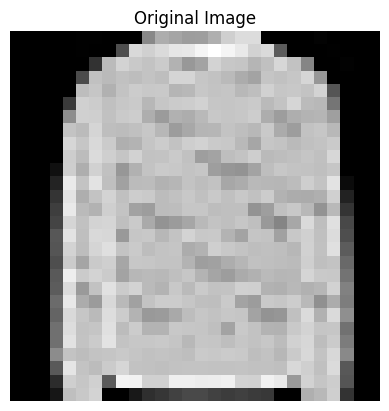

In [52]:
plt.imshow(
    image.squeeze(),
    cmap="gray"
)
plt.title("Original Image")
plt.axis("off")
plt.show()

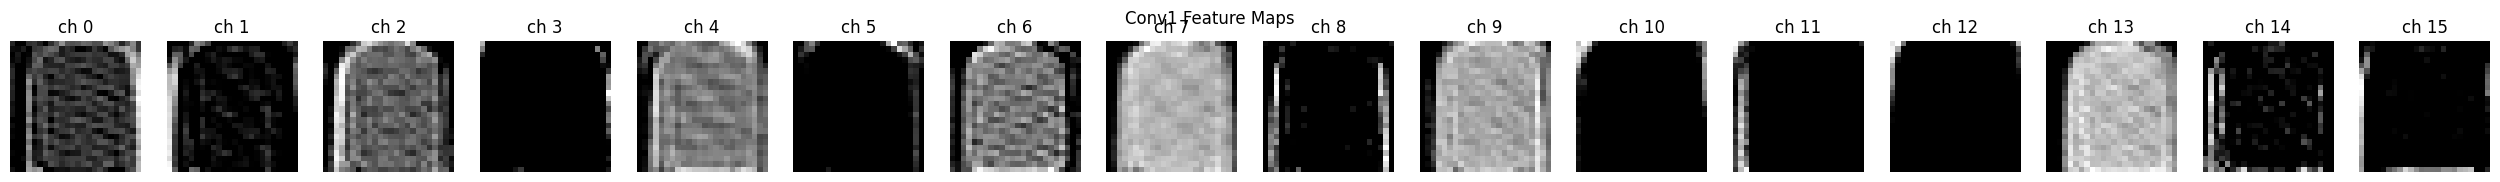

In [53]:
show_channels(
    conv1_out,
    "Conv1 Feature Maps"
)

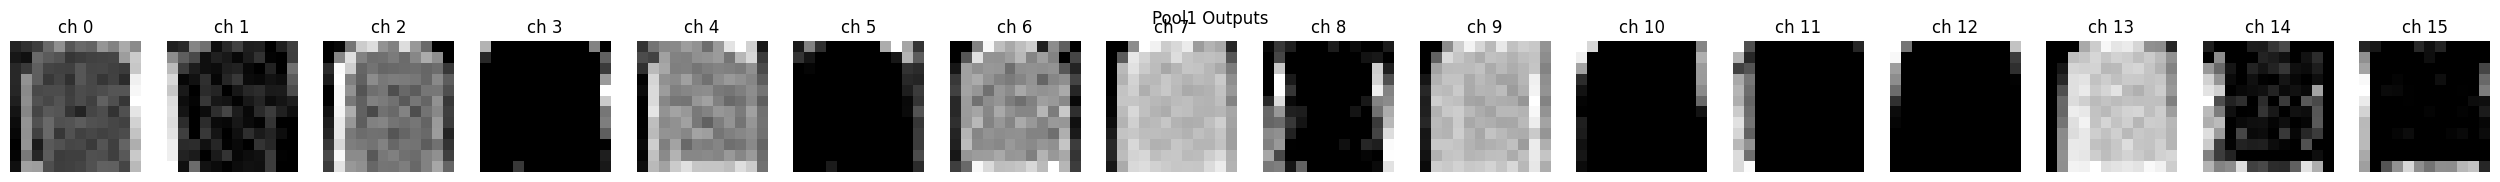

In [54]:
show_channels(
    pool1_out,
    "Pool1 Outputs"
)

In [55]:
def show_grid(tensor, title):

    tensor = tensor.squeeze(0)

    n = tensor.shape[0]

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(8,8)
    )

    axes = axes.flatten()

    for i in range(n):

        axes[i].imshow(
            tensor[i].detach().cpu(),
            cmap="gray"
        )

        axes[i].set_title(str(i))
        axes[i].axis("off")

    plt.suptitle(title)
    plt.show()

IndexError: index 16 is out of bounds for axis 0 with size 16

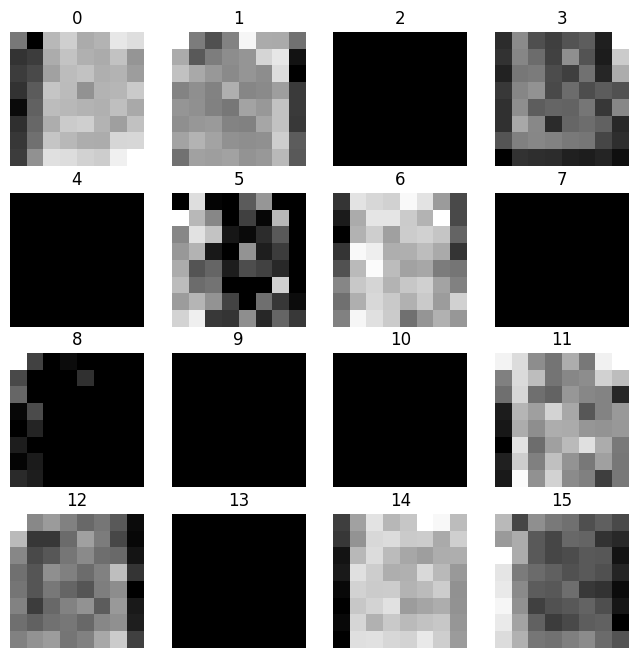

In [56]:
show_grid(
    conv2_out,
    "Conv2 Feature Maps"
)

### 3.3 Neural Network Training

#### 3.3.1 Preparing training

In [38]:
# specify the training parameters
num_epochs = 30 # number of training epochs
mini_batch_size = 128 # size of the mini-batches - lets start small cause the dataset is not too big

In [39]:
fashion_mnist_train_dataloader = torch.utils.data.DataLoader(fashion_mnist_train_data, batch_size=mini_batch_size, shuffle=True)

#### 3.3.2 Running Network Training

In [40]:

train_epoch_losses = []

for epoch in range(num_epochs):

    model.train()
    train_mini_batch_losses = []

    for i, (images, labels) in enumerate(fashion_mnist_train_dataloader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        output = model(images)

        loss = nll_loss(output, labels)

        loss.backward()

        optimizer.step()

        train_mini_batch_losses.append(loss.item())

    train_epoch_loss = np.mean(train_mini_batch_losses)
    train_epoch_losses.append(train_epoch_loss)

    now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
    print(f"[LOG {now}] epoch: {epoch} train-loss: {train_epoch_loss}")

    model_name = f"fashion_mnist_model_epoch_{epoch}.pth"
    torch.save(
        model.state_dict(),
        os.path.join(models_directory, model_name)
    )


[LOG 20260627-08:25:49] epoch: 0 train-loss: 1.9275293525602264
[LOG 20260627-08:26:05] epoch: 1 train-loss: 0.8978572508165323
[LOG 20260627-08:26:20] epoch: 2 train-loss: 0.743755311345749
[LOG 20260627-08:26:36] epoch: 3 train-loss: 0.6548662625396175
[LOG 20260627-08:26:51] epoch: 4 train-loss: 0.5860266055760861
[LOG 20260627-08:27:06] epoch: 5 train-loss: 0.5365887200400266
[LOG 20260627-08:27:21] epoch: 6 train-loss: 0.49953315163980416
[LOG 20260627-08:27:37] epoch: 7 train-loss: 0.47338864957091653
[LOG 20260627-08:27:53] epoch: 8 train-loss: 0.45093181862759946
[LOG 20260627-08:28:08] epoch: 9 train-loss: 0.4309612497337846
[LOG 20260627-08:28:24] epoch: 10 train-loss: 0.4132804598000004
[LOG 20260627-08:28:39] epoch: 11 train-loss: 0.3984869510761456
[LOG 20260627-08:28:54] epoch: 12 train-loss: 0.38537561413702937
[LOG 20260627-08:29:09] epoch: 13 train-loss: 0.3742138907027397
[LOG 20260627-08:29:25] epoch: 14 train-loss: 0.36492088068522877
[LOG 20260627-08:29:40] epoch: 

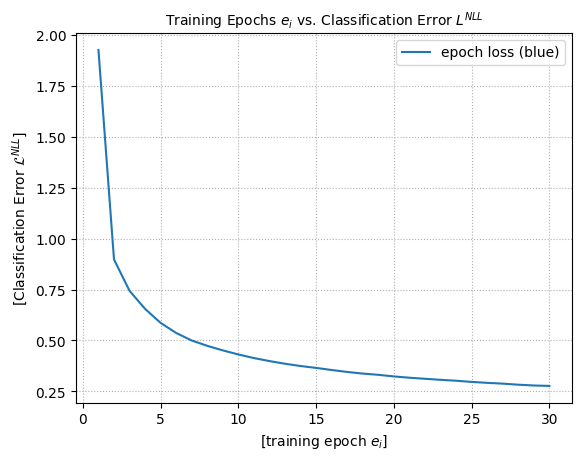

In [41]:
# prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# add grid
ax.grid(linestyle='dotted')

# plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(train_epoch_losses)+1)), train_epoch_losses, label='epoch loss (blue)')

# add axis legends
ax.set_xlabel("[training epoch $e_i$]", fontsize=10)
ax.set_ylabel("[Classification Error $\\mathcal{L}^{NLL}$]", fontsize=10)

# set plot legend
plt.legend(loc="upper right", numpoints=1, fancybox=True)

# add plot title
plt.title('Training Epochs $e_i$ vs. Classification Error $L^{NLL}$', fontsize=10);

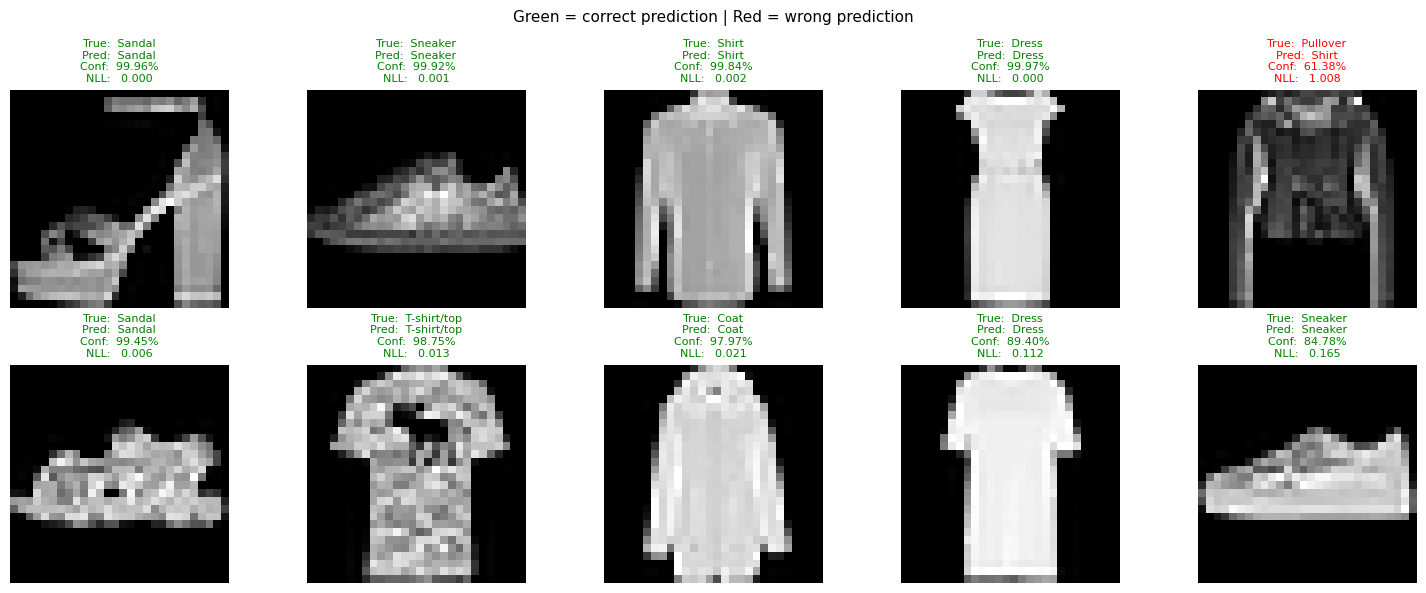

In [42]:
model.eval()

# pick 10 random samples from training data
indices = np.random.choice(len(fashion_mnist_train_data), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(indices):
        image, true_label = fashion_mnist_train_data[idx]

        # run forward pass on single image
        output = model(image.unsqueeze(0).to(device))  # [1, 1, 28, 28]

        # get probabilities from log-softmax output
        probs = torch.exp(output)                       # convert log-probs → probs
        confidence, predicted_label = probs.max(dim=1)

        predicted_label = predicted_label.item()
        confidence      = confidence.item()
        nll             = -torch.log(probs[0, true_label]).item()  # NLL for this sample

        # plot
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].axis('off')

        correct = predicted_label == true_label
        color   = 'green' if correct else 'red'

        axes[i].set_title(
            f'True:  {fashion_labels[true_label]}\n'
            f'Pred:  {fashion_labels[predicted_label]}\n'
            f'Conf:  {confidence:.2%}\n'
            f'NLL:   {nll:.3f}',
            fontsize=8, color=color
        )

plt.suptitle('Green = correct prediction | Red = wrong prediction', fontsize=11)
plt.tight_layout()
plt.show()

### 3.4 Evaluating Model

In [43]:
# find epoch with lowest training loss
best_epoch = int(np.argmin(train_epoch_losses))
best_model_name = os.path.join(models_directory, f'fashion_mnist_model_epoch_{best_epoch}.pth')

model.load_state_dict(torch.load(best_model_name, map_location=device))
model.eval()
print(f'[LOG] Best epoch: {best_epoch} | Loss: {train_epoch_losses[best_epoch]:.4f}')

[LOG] Best epoch: 29 | Loss: 0.2764


In [44]:
# set best model path
best_model_name = os.path.join(models_directory, 'fashion_mnist_model_epoch_19.pth')

# init model and load weights directly from local path
best_model = FashionMNISTNet()
best_model.load_state_dict(torch.load(best_model_name, map_location=device))
best_model = best_model.to(device)
best_model.eval()

print(f'[LOG] Model loaded: {best_model_name}')

[LOG] Model loaded: /content/drive/MyDrive/Colab Notebooks/models/fashion_mnist_model_epoch_19.pth


In [45]:
# set model in evaluation mode
best_model.eval()

FashionMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=512, out_features=120, bias=True)
  (relu1): ReLU(inplace=True)
  (linear2): Linear(in_features=120, out_features=84, bias=True)
  (relu2): ReLU(inplace=True)
  (linear3): Linear(in_features=84, out_features=10, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)

In [46]:
fashion_mnist_eval_dataloader = torch.utils.data.DataLoader(fashion_mnist_eval_data, batch_size=100, shuffle=False)

In [47]:
eval_mini_batch_losses = []

best_model.eval()

with torch.no_grad():                          #  no gradients needed for eval
    for i, (images, labels) in enumerate(fashion_mnist_eval_dataloader):

        images = images.to(device)             #  missing in your current code
        labels = labels.to(device)             #  missing in your current code

        output = best_model(images)

        loss = nll_loss(output, labels)
        eval_mini_batch_losses.append(loss.data.item())

eval_loss = np.mean(eval_mini_batch_losses)

now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
print('[LOG {}] eval-loss: {}'.format(str(now), str(eval_loss)))

[LOG 20260627-08:33:44] eval-loss: 0.35728714063763617


[LOG] Train accuracy: 88.40%
[LOG] Eval accuracy:  87.45%
[LOG] Gap:            0.95%

[LOG] Train and eval accuracy are close; generalization looks reasonable.

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.84      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.82      0.80      1000
       Dress       0.83      0.91      0.87      1000
        Coat       0.76      0.83      0.80      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.78      0.56      0.65      1000
     Sneaker       0.92      0.95      0.93      1000
         Bag       0.94      0.97      0.96      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



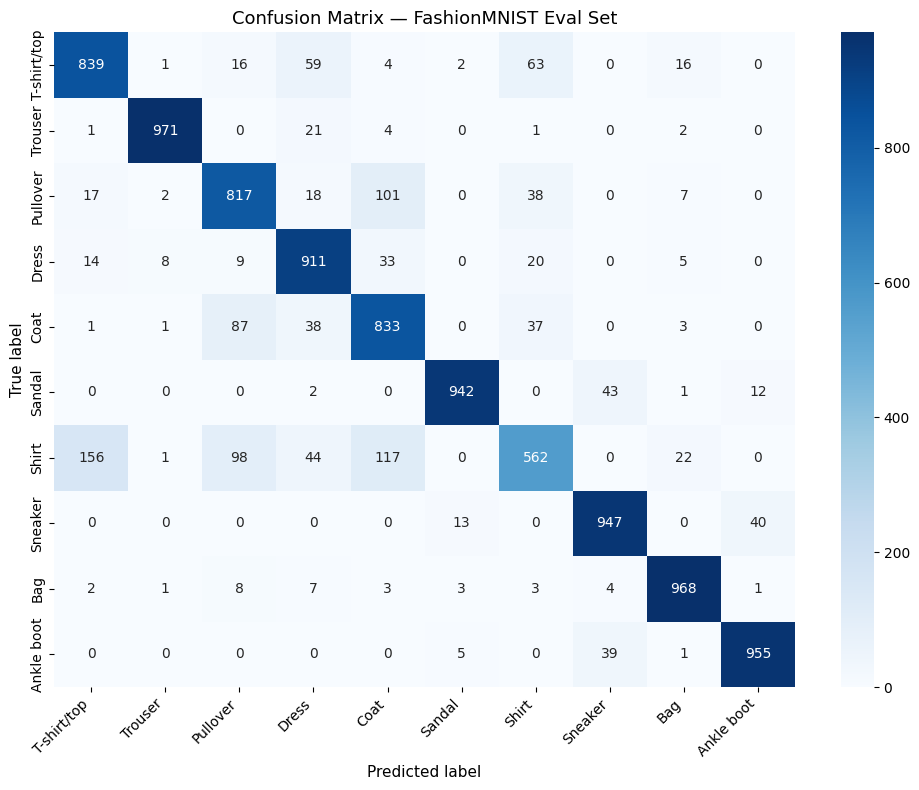

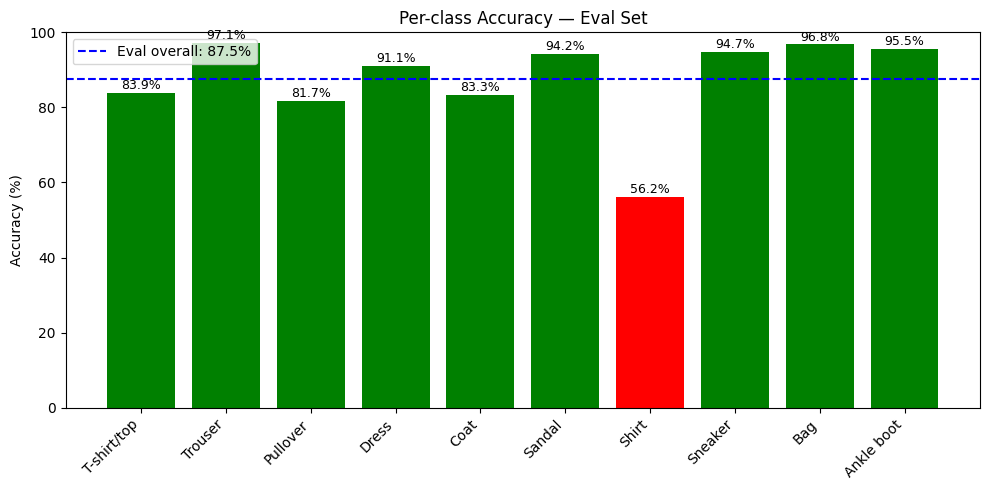

In [48]:
best_model.eval()

def get_accuracy(model, dataloader, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            preds = torch.argmax(output, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return metrics.accuracy_score(all_labels, all_preds), np.array(all_labels), np.array(all_preds)


# ── 1. TRAIN VS EVAL ACCURACY ───────────────────────────────────────────────
train_acc, _, _ = get_accuracy(
    best_model,
    fashion_mnist_train_dataloader,
    device
)

eval_acc, all_labels, all_preds = get_accuracy(
    best_model,
    fashion_mnist_eval_dataloader,
    device
)

print(f"[LOG] Train accuracy: {train_acc * 100:.2f}%")
print(f"[LOG] Eval accuracy:  {eval_acc * 100:.2f}%")
print(f"[LOG] Gap:            {(train_acc - eval_acc) * 100:.2f}%\n")

if train_acc - eval_acc > 0.05:
    print("[LOG] Likely overfitting: train accuracy is much higher than eval accuracy.\n")
elif eval_acc > train_acc:
    print("[LOG] Eval accuracy is higher than train accuracy.\n")
else:
    print("[LOG] Train and eval accuracy are close; generalization looks reasonable.\n")


# ── 2. PER-CLASS BREAKDOWN ON EVAL SET ──────────────────────────────────────
print(classification_report(
    all_labels,
    all_preds,
    target_names=list(fashion_labels.values())
))


# ── 3. CONFUSION MATRIX ON EVAL SET ─────────────────────────────────────────
mat = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(fashion_labels.values()),
    yticklabels=list(fashion_labels.values()),
    ax=ax
)

ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("Confusion Matrix — FashionMNIST Eval Set", fontsize=13)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ── 4. PER-CLASS ACCURACY BAR CHART ON EVAL SET ─────────────────────────────
per_class_acc = mat.diagonal() / mat.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    list(fashion_labels.values()),
    per_class_acc * 100,
    color=[
        "green" if a >= 0.80 else "orange" if a >= 0.70 else "red"
        for a in per_class_acc
    ]
)

ax.axhline(
    y=eval_acc * 100,
    color="blue",
    linestyle="--",
    label=f"Eval overall: {eval_acc * 100:.1f}%"
)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-class Accuracy — Eval Set")
ax.set_ylim(0, 100)

plt.xticks(rotation=45, ha="right")
plt.legend()

for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc * 100:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()